## **4-Pixel Odometry Simulator Tutorial**

In this notebook we show the full simulator pipeline covering:
1. Sensor Views extractions along kinematic paths
2. 4-Pixel signals simulation
3. Demo odometry integration with pre-trained 4-Pixel model

### **4-Pixel Views Simulator**
Here we load the TartanFullTrajectoryDataset class.
This class simulates the motion of the sensor and extracts the 4 pixel views based on long kinematic paths.
N.B. This is not the Dataset class that we use for training the model as that one loads independent 'windows' of data and not full kinematic paths

The first cell, shows the path of the sensor over stiched high-resolution textures
The second cell, renders a video, showing the sensor motion over the textures, and the independent detector views extracted during the motion

Found 7293 images ...
Filtered out {'elastomer', 'fiber', 'porcelain', 'thermoplastic', 'brass', 'silk', 'thermoset', 'polyester', 'iron', 'glass', 'aluminum', 'paint', 'bronze', 'steel', 'copper'} textures
Remaining: 7293
Initialized training set with 5105 textures.
Initialized validation set with 729 textures.
Initialized test set with 1459 textures.
Target shape is 3024x4032. Loading and filtering images concurrently...
Using 8 threads ...
Skipped 9 images with incorrect dimensions.
Loading 720 images of shape 3024x4032
Estimated memory (uint8): 11.628 MB per image, 8.18 GB total
System RAM total: 251.31 GB, available: 180.82 GB
Allocated shared tensor and called share_memory_()
All images loaded into shared tensor.
Found 198 trajectory folders. Loading full trajectories ...
Mode: test. Using 40 full trajectories out of 198.


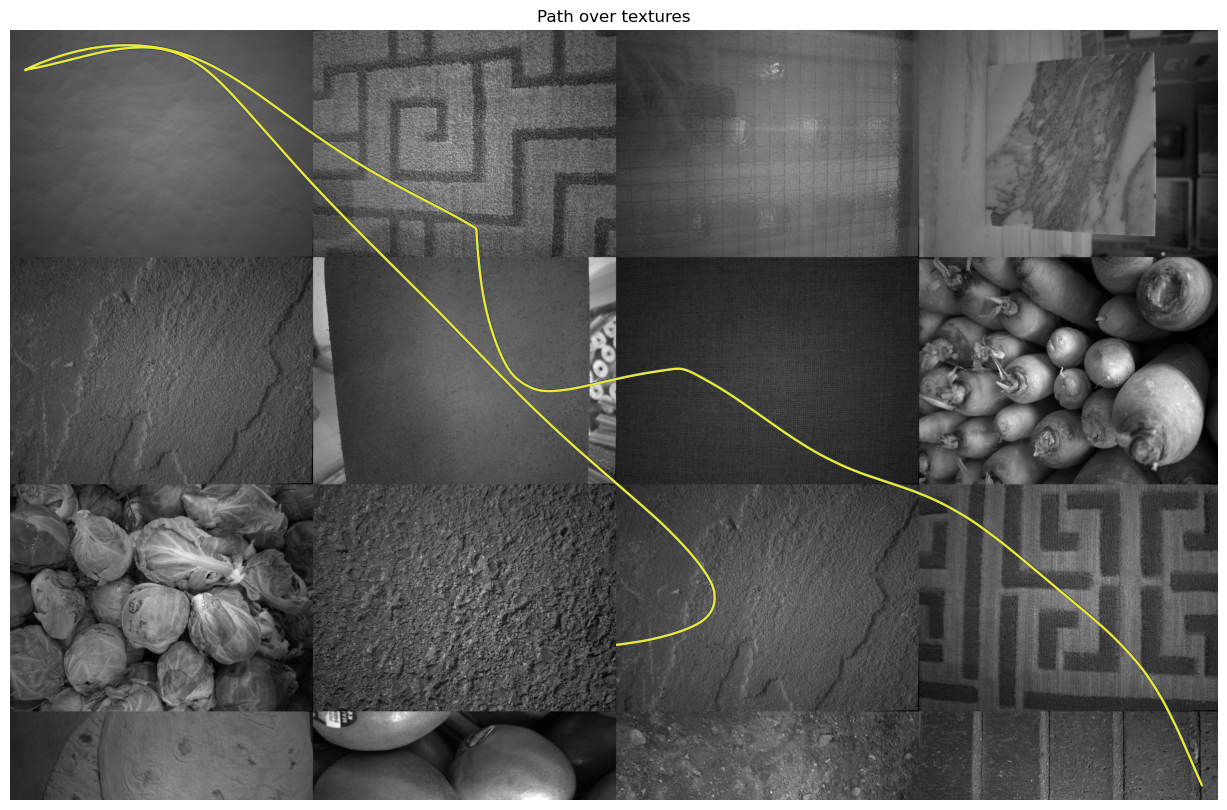

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from simulator.views_simulator import TartanFullTrajectoryDataset, MetaGridStreamer, matador_paths, preload_to_tensor
from torch.utils.data import DataLoader

# Adjust these paths based on where you downloaded the datasets
texture_path = '/media/data/Datasets/matador/sensor_gray'
label_path = '/media/data/Datasets/matador/labels'
tartan_trajectories_path = '/media/data/Datasets/Tartan'

##Load all of the matador images in a shared memory tensor (might require High RAM usage, in case reduce the number of paths loaded into tensor by doing val_paths[:100])
train_paths, val_paths, test_paths = matador_paths(Path(texture_path), Path(label_path), context_folder=None, random_seed=42, split_ratios=(0.7, 0.1, 0.2))
test_img_tensor, test_paths_loaded = preload_to_tensor(val_paths, n_threads=8)

test_sim = TartanFullTrajectoryDataset(
    test_img_tensor,
    test_paths_loaded,
    trajectory_root_dir=tartan_trajectories_path,
    height_range = [0.20,0.20], #Height of the sensor from the ground
    camera_fov = 70.0, #Single detecor field of view
    mode = 'test',
    camera_displacement=0.019, #Displacement between adjacent detectors
    
)

test_sim_loader = DataLoader(
    test_sim, 
    batch_size=1, 
    shuffle=False, 
    pin_memory=False, 
    num_workers=0,
    persistent_workers=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

i = 0
for item in test_sim_loader:
    if i == 0:
        break

# Plot the pano image
pano_image = item['pano'].squeeze().cpu().numpy()
plt.figure(figsize=(20, 10))
stride_img = 4 # Shrinks just to save memory
plt.imshow(pano_image[::stride_img, ::stride_img], cmap='gray', vmin=0, vmax=1)
plt.title("Path over textures")
plt.axis('off')

colors = plt.cm.viridis(np.linspace(0, 1, item['offsets'].shape[1]))
offsets = item['offsets'].squeeze().cpu().numpy() 

stride_path = 100
for cam_idx in range(offsets.shape[0]):
    path = offsets[cam_idx]     
    path_x = path[::stride_path, 0] / stride_img
    path_y = path[::stride_path, 1] / stride_img
    plt.plot(path_x, path_y, color=colors[cam_idx], label=f'Cam{cam_idx}')

plt.show()


In [2]:
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio
import math
from IPython.display import Video

# ==========================================
# RENDER CONTROLS
# ==========================================
MAX_VIDEO_SECONDS = 10.0  # Set to None to render the full trajectory
video_fps = 30 
sim_freq = 1000 
stride = int(sim_freq / video_fps)
outfile = "data/demo-videos/sensor_views.mp4"

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def tile_cams(frame_cams: torch.Tensor):
    """Hardcoded for 4 views (2x2 grid)"""
    C, h, w = frame_cams.shape
    canvas = torch.zeros(2*h, 2*w, dtype=frame_cams.dtype)
    for i in range(min(C, 4)):
        r, c = divmod(i, 2)
        canvas[r*h:(r+1)*h, c*w:(c+1)*w] = frame_cams[i]
    return canvas

def make_palette():
    """Returns 4 highly distinct, bright colors for the 4 pixels"""
    # Cyan, Orange, Lime Green, Magenta
    return [(23, 190, 207), (255, 127, 14), (44, 160, 44), (227, 119, 194)]

def clamp_int(v, lo, hi):
    return int(max(lo, min(hi, v)))

def draw_boxes_on_pil_rotated(img_pil: Image.Image, centers_xy: np.ndarray,
                              theta: float, win: int, h: int, crop_xy0: tuple,
                              colors: list, thickness: int = 2):
    draw = ImageDraw.Draw(img_pil)
    x0c, y0c = crop_xy0
    hw, hh = win / 2.0, h / 2.0
    
    box = np.array([[-hw, -hh], [ hw, -hh], [ hw,  hh], [-hw,  hh], [-hw, -hh]], dtype=np.float32)
    c, s = math.cos(theta), math.sin(theta)
    R = np.array([[c, -s], [s, c]], dtype=np.float32)
    
    for i, (cx, cy) in enumerate(centers_xy):
        pts = (box @ R.T) + np.array([cx - x0c, cy - y0c], dtype=np.float32)
        pts = [tuple(map(float, p)) for p in pts]
        draw.line(pts, fill=colors[i % 4], width=thickness, joint="curve")
    return img_pil

def compute_fixed_crop_windows(offsets: torch.Tensor, win: int, h: int,
                               pad: int, pano_w: int, pano_h: int):
    xs, ys = offsets[..., 0], offsets[..., 1]
    half_w, half_h = win / 2.0, h / 2.0

    x_min_t, x_max_t = xs.min(dim=0).values - half_w, xs.max(dim=0).values + half_w
    y_min_t, y_max_t = ys.min(dim=0).values - half_h, ys.max(dim=0).values + half_h

    w_t, h_t = (x_max_t - x_min_t) + 2 * pad, (y_max_t - y_min_t) + 2 * pad
    W_left, H_left = int(math.ceil(w_t.max().item())), int(math.ceil(h_t.max().item()))

    cx_t, cy_t = (x_min_t + x_max_t) / 2.0, (y_min_t + y_max_t) / 2.0

    x0 = torch.floor(cx_t - W_left / 2.0).clamp(min=0, max=max(0, pano_w - W_left))
    y0 = torch.floor(cy_t - H_left / 2.0).clamp(min=0, max=max(0, pano_h - H_left))
    
    bboxes = torch.stack([x0, y0, x0 + W_left, y0 + H_left], dim=1).to(torch.int64)
    return bboxes, H_left, W_left


def make_composite_frame_optimized(pano_pil: Image.Image, crop_bbox: torch.Tensor,
                                   centers_xy: torch.Tensor, theta_t: float,
                                   cams_tiled: torch.Tensor, colors: list,
                                   win: int, h: int, box_thickness: int = 2):
    
    # 1. Background Crop
    x0, y0, x1, y1 = map(int, crop_bbox.tolist())
    crop_img = pano_pil.crop((x0, y0, x1, y1))

    # 2. Draw Boxes
    crop_img = draw_boxes_on_pil_rotated(
        crop_img, centers_xy.detach().cpu().numpy(),
        theta=float(theta_t), win=win, h=h, crop_xy0=(x0, y0),
        colors=colors, thickness=box_thickness
    )

    # 3. Tiled Cameras (Right side)
    right = np.clip(cams_tiled.detach().cpu().numpy(), 0, 1)
    right_rgb = (np.stack([right, right, right], axis=-1) * 255.0).astype(np.uint8)
    right_img = Image.fromarray(right_rgb)

    # 4. Resize Left to match Right Height
    target_h = right_img.height
    if crop_img.height != target_h:
        new_w = int(round(crop_img.width * (target_h / crop_img.height)))
        resample_filter = getattr(Image.Resampling, 'BILINEAR', Image.BILINEAR)
        crop_img = crop_img.resize((new_w, target_h), resample=resample_filter)

    # 5. Create Master Canvas with a Header Bar for Titles
    HEADER_H = 40
    out_w = crop_img.width + right_img.width
    out_h = target_h + HEADER_H
    
    # Dark gray background for the header
    out = Image.new('RGB', (out_w, out_h), (35, 35, 35)) 
    
    # Draw Titles
    draw = ImageDraw.Draw(out)
    
    # Left Title
    draw.text((10, 8), "Sensor Motion", fill=(255, 255, 255))
    # Right Title
    draw.text((crop_img.width + 10, 8), "4-Pixel Views", fill=(255, 255, 255))

    # 6. Paste Images Below Header
    out.paste(crop_img, (0, HEADER_H))
    out.paste(right_img, (crop_img.width, HEADER_H))
    
    return np.asarray(out, dtype=np.uint8)

# ==========================================
# EXECUTION SCRIPT
# ==========================================

device = 'cuda' if torch.cuda.is_available() else 'cpu'

pano_cpu    = item['pano'].squeeze(0).contiguous()      
offsets_cpu = item['offsets'].squeeze(0).contiguous()   
thetas_cpu  = item['thetas'].squeeze(0).contiguous()    

# Enforce exactly 4 views
num_cams, T, _ = offsets_cpu.shape
assert num_cams == 4, f"Expected 4 cameras, got {num_cams}. Check your dataset loader."

if MAX_VIDEO_SECONDS is not None:
    max_sim_steps = int(MAX_VIDEO_SECONDS * video_fps * stride)
    T_clip = min(T, max_sim_steps)
else:
    T_clip = T

print(f"Rendering {T_clip // stride} frames at {video_fps} FPS...")

offsets_clip = offsets_cpu[:, :T_clip].contiguous()
thetas_clip  = thetas_cpu[:T_clip].contiguous()

H_p, W_p = pano_cpu.shape
pad_px = 64
bboxes_by_t, H_left, W_left = compute_fixed_crop_windows(
    offsets_clip, win=128, h=128, pad=pad_px, pano_w=W_p, pano_h=H_p
)

streamer = MetaGridStreamer(h=128, win=128, num_cams=num_cams).to(device)

print("Pre-processing panorama...")
pano_np = np.clip(pano_cpu.numpy(), 0, 1) 
if pano_np.ndim == 3: pano_np = pano_np.squeeze(0)
pano_rgb = (np.stack([pano_np, pano_np, pano_np], axis=-1) * 255.0).astype(np.uint8)
pano_pil_global = Image.fromarray(pano_rgb) 

writer = imageio.get_writer(outfile, fps=video_fps, macro_block_size=2)

chunk_len = 16
t_global = 0
master_colors = make_palette() # Now returns exactly 4 clean colors

for chunk in streamer.stream(
    pano=pano_cpu.to(device),
    all_offsets=offsets_clip.to(device),
    thetas=thetas_clip.to(device),
    chunk_len=chunk_len,
    device=device
):
    for t in range(chunk.shape[1]):
        if t_global >= T_clip:
            break
            
        if t_global % stride == 0:
            cams_t = chunk[:, t, 0]
            # No rows/cols parameters needed, explicitly handles 2x2
            tiled = tile_cams(cams_t.cpu()) 
            centers_t = offsets_clip[:, t_global, :]
            theta_t   = float(thetas_clip[t_global].item())

            frame_rgb = make_composite_frame_optimized(
                pano_pil=pano_pil_global,
                crop_bbox=bboxes_by_t[t_global],
                centers_xy=centers_t,
                theta_t=theta_t,
                cams_tiled=tiled,
                colors=master_colors, 
                win=128,
                h=128,
                box_thickness=3 
            )
            writer.append_data(frame_rgb)
            
            rendered_frames = t_global // stride
            total_frames = T_clip // stride
            print(f"Rendered frame {rendered_frames} / {total_frames} (Video Time: {(t_global/sim_freq):.2f}s)", end='\r')

        t_global += 1

    if t_global >= T_clip:
        break

writer.close()
print(f"\nSuccess! Video saved to {outfile}")

# Embed video in notebook
Video(
    outfile, 
    embed=True, 
    width=800, 
    html_attributes="controls loop autoplay muted"
)

Rendering 300 frames at 30 FPS...
Pre-processing panorama...


/tmp/ipykernel_2274681/654606650.py:99: DeprecationWarning: BILINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BILINEAR instead.
  resample_filter = getattr(Image.Resampling, 'BILINEAR', Image.BILINEAR)


Rendered frame 299 / 300 (Video Time: 9.87s)
Success! Video saved to data/demo-videos/sensor_views.mp4


### **4-Pixel Sensor Signals simulator**
Here we show how given the independent views we simulate the 4 masked detector signals.

First, we show the masks of the model.
Then an example signal.

Photodiode kernel size: 7x7


/tmp/ipykernel_2274681/1240589215.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


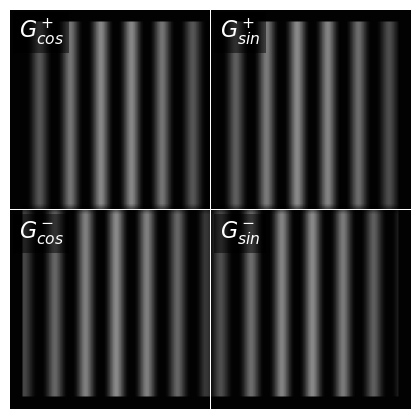

In [3]:
from simulator.cam_models import GaborCam
import cv2
import matplotlib.pyplot as plt

model = GaborCam(
    realistic_sensor=True, #simulates sensor noise and quantization noise
    simulate_pd_area_blur=True, #simulates the blur kernel given by the photodiode active area
    simulate_solid_angle=True, #simulates fortshortening of light at the edges of the field of view
    mask_min_value=0.009882269613863095, #min of the printer transfer function (black is not fully black when printed on transparency)
    mask_max_value=0.6721403856424802, #max of the printer transfer function (black is not fully black when printed on transparency)
    simulate_directivity=True, #simulates of the photodiode directivity
    sensor_gain=0.0012243347290119763, #gain for hamamatsu photodiodes
    sensor_n_bits=16, #to simulate quantization noise
    sensor_saturation_val=3.2, #saturation value of the sensor (in Volts)
    read_noise_std=0.000175, #read noise of the sensor (in Volts)
    model_vert_fov=70, #detector FOV (should match the view simulator)
    model_horiz_fov=70, #detector FOV (should match the view simulator)
    init_freqs=[8.0], #frequency of the Gabor masks (in cycles per mask)
    height=0.20, #Height of the sensor relative to the ground plane
    camera_displacement=0.019, #inter-detector displacement (shuld match the view simulator)
    differential_overlap=False, #If True Only Positive/negative pair masks are aligned so that they see the same area of the mask
    full_masks=False, #If True masks are not aligned
    debug_mode=True #returns also the simulated sensor signal
    )

#Load pre-trained model
model_path = 'data/models/demo_model.pth'
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict, strict=False)
model.to(device)
model.eval()

#Here we visualize the trained masks
masks = model.visualize_overlap_masks() 
layout = [2, 3, 0, 1]
titles = [r"$G_{cos}^+$", r"$G_{sin}^+$", r"$G_{cos}^-$", r"$G_{sin}^-$"]

# Added a small 'hspace' so the bottom titles don't overlap the top row
fig, axs = plt.subplots(2, 2, figsize=(4, 4), gridspec_kw={'wspace': 0.01, 'hspace': 0.0}) 
axs = axs.flatten()

for plot_idx, view_idx in enumerate(layout):
    mask = masks[view_idx].permute(1, 2, 0).cpu().numpy()
    mask = (mask * 255).astype(np.uint8)
    axs[plot_idx].imshow(mask)
    axs[plot_idx].axis('off')
    axs[plot_idx].text(5, 18, titles[plot_idx], color='white', fontsize=16, 
                       bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
    
plt.subplots_adjust(left=0, right=1, bottom=0, top=1) 
plt.show()


(tensor([[1.8269]], device='cuda:0'), tensor([[-7.2904]], device='cuda:0'))


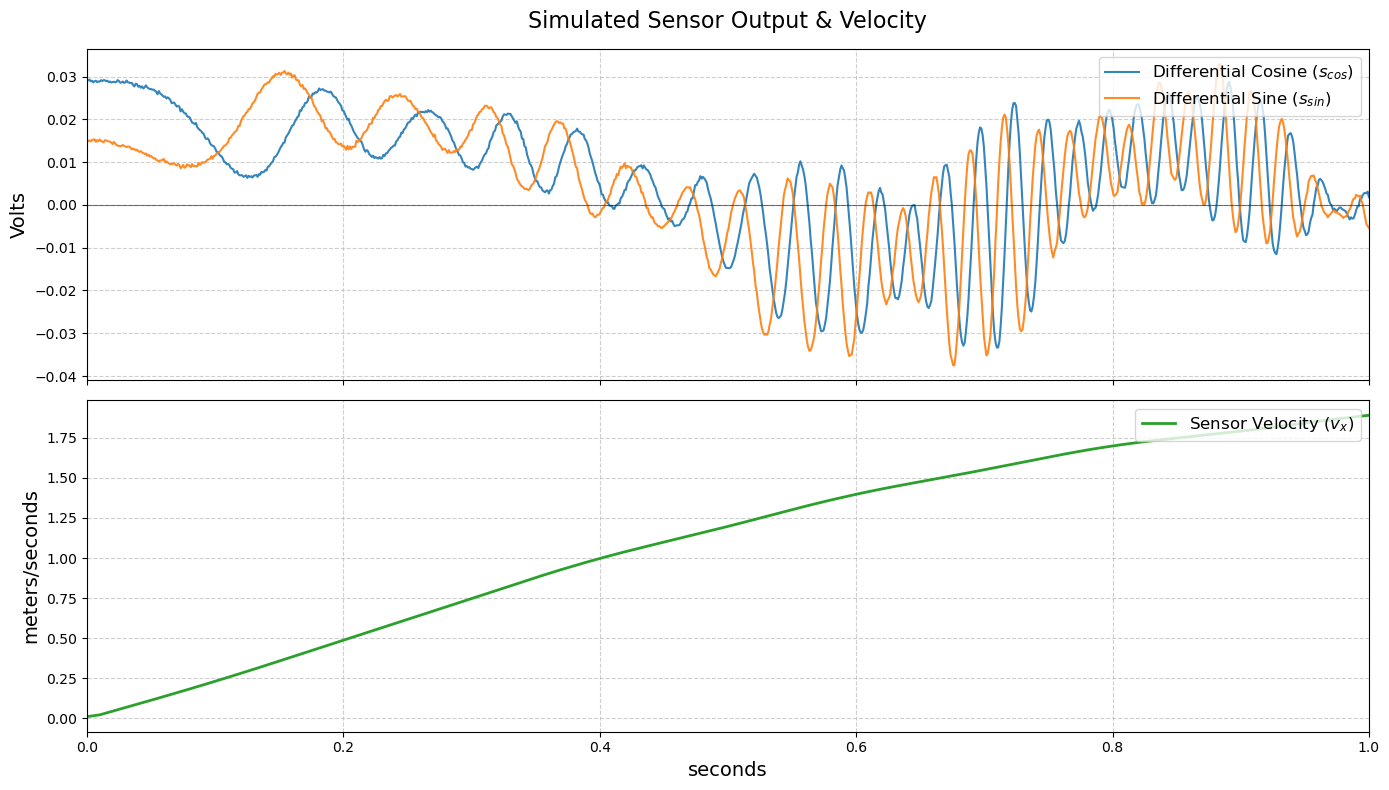

In [4]:
chunk_len = 1000 #How many ms of data to plot
stream = streamer.stream(
    pano=item['pano'].squeeze(0).to(device),
    all_offsets=item['offsets'].squeeze(0).to(device),
    thetas=item['thetas'].squeeze(0).to(device),
    chunk_len=chunk_len,
    device=device
)
first_chunk = next(stream) #[C=4, S=1000, Ch=1, H=128, W=128]
model_input = first_chunk.unsqueeze(0)

with torch.no_grad():
    pred_vx, raw_signals, norm_signals = model(model_input)

s_cos = raw_signals[0, 0, :].cpu().numpy()
s_sin = raw_signals[0, 1, :].cpu().numpy()

print(pred_vx)

velocity = item['vel'].squeeze(0)[:chunk_len, 0].cpu().numpy() #v_x ground truth
time_axis = np.linspace(0, 1.0, chunk_len)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(time_axis, s_cos, label=r"Differential Cosine ($s_{cos}$)", color='#1f77b4', linewidth=1.5, alpha=0.9)
ax1.plot(time_axis, s_sin, label=r"Differential Sine ($s_{sin}$)", color='#ff7f0e', linewidth=1.5, alpha=0.9)
ax1.set_title("Simulated Sensor Output & Velocity", fontsize=16, pad=15)
ax1.set_ylabel("Volts", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5) # Center line
ax1.legend(loc="upper right", fontsize=12)
ax2.plot(time_axis, velocity, label=r"Sensor Velocity ($v_x$)", color='#2ca02c', linewidth=2)
ax2.set_xlabel('seconds', fontsize=14)
ax2.set_ylabel('meters/seconds', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc="upper right", fontsize=12)

plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

### **Odometry**
Here we show the odometry performance on the simulated path.

The pre-trained TCN decoder is used to estimate the sensor linear velocity (v_x) given the simulated sensor signals.
To compute the odometry we also generate simulated angular velocity (w_z) readings on a ICM-42605 IMU.

Simulating 45.4 seconds of trajectory...
Running batched TCN decoder over 44392 windows...


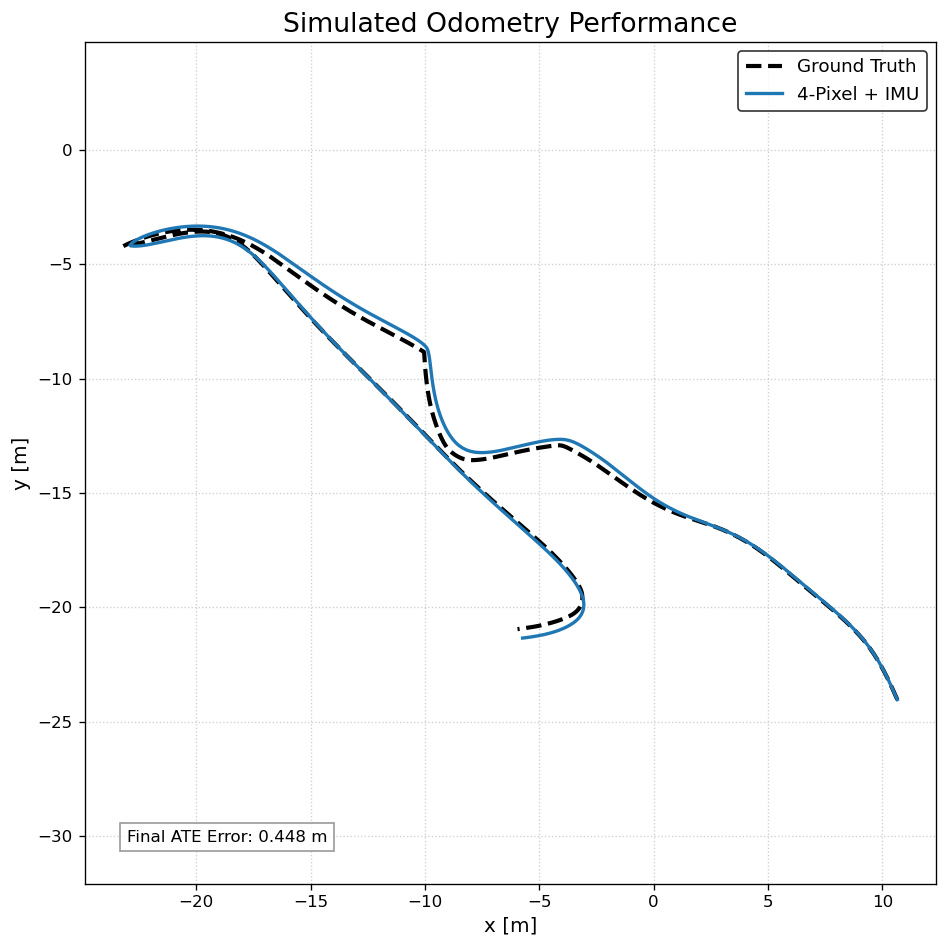

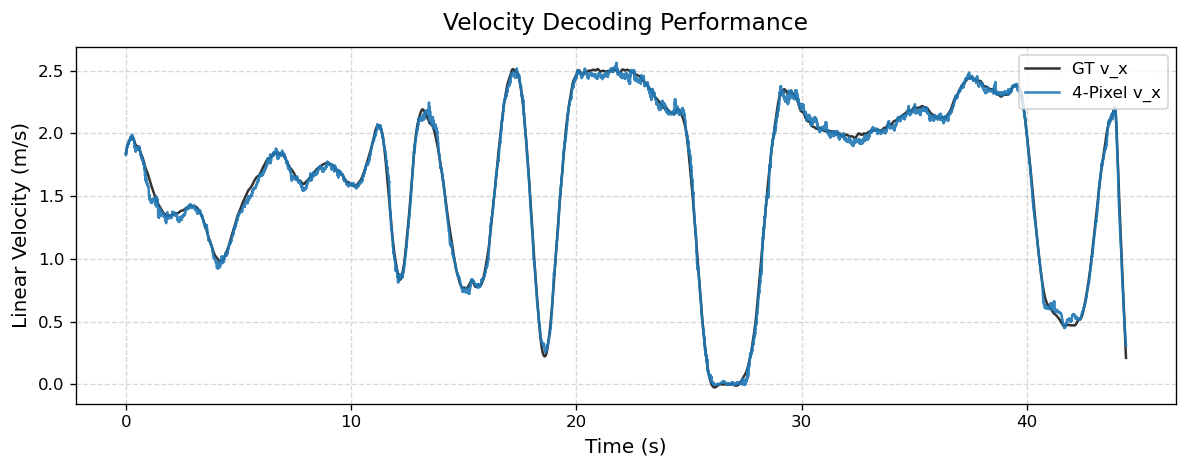

In [5]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

class IMUSimulator:
    def __init__(self, freq=1000.0, calibrated=True, seed=42):
        self.rng = np.random.default_rng(seed)
        self.dt = 1.0 / freq
        self.g = 9.80665
        dps_to_rad = np.pi / 180.0

        # Noise & Bias properties (ICM-42605 typicals)
        self.nd_gyro = 0.0038 * dps_to_rad
        self.nd_accel = (70e-6) * self.g
        self.rrw_gyro = self.nd_gyro / 20.0 
        self.rrw_accel = self.nd_accel / 20.0
        self.bias_limit_gyro = 0.5 * dps_to_rad
        self.bias_limit_accel = (40e-3) * self.g
        
        self.sf_limit = 0.005
        self.misalignment_limit = 0.005
        self.res_factor = 0.05 if calibrated else 1.0
        
        self._init_static_errors()

    def _init_static_errors(self):
        self.b_g_static = self.rng.choice([-1, 1], size=3) * self.bias_limit_gyro * self.res_factor
        self.b_a_static = self.rng.choice([-1, 1], size=3) * self.bias_limit_accel * self.res_factor

        self.S_g = np.diag(1.0 + self.rng.choice([-1, 1], size=3) * self.sf_limit)
        self.S_a = np.diag(1.0 + self.rng.choice([-1, 1], size=3) * self.sf_limit)

        self.M_g, self.M_a = np.eye(3), np.eye(3)
        for i in range(3):
            for j in range(3):
                if i != j:
                    self.M_g[i,j] = self.rng.choice([-1, 1]) * self.misalignment_limit
                    self.M_a[i,j] = self.rng.choice([-1, 1]) * self.misalignment_limit

    def simulate(self, accel_true_vec, gyro_true_vec):
        N = len(accel_true_vec)
        
        # Stochastic Noise (White Noise + Random Walk)
        wn_g = self.rng.normal(0, self.nd_gyro / np.sqrt(self.dt), (N, 3))
        wn_a = self.rng.normal(0, self.nd_accel / np.sqrt(self.dt), (N, 3))
        
        bias_step_g = self.rng.normal(0, self.rrw_gyro * np.sqrt(self.dt), (N, 3))
        bias_step_a = self.rng.normal(0, self.rrw_accel * np.sqrt(self.dt), (N, 3))
        bias_walk_g = np.cumsum(bias_step_g, axis=0)
        bias_walk_a = np.cumsum(bias_step_a, axis=0)

        # Apply Sensor Model
        gyro_det = ((self.M_g @ self.S_g) @ gyro_true_vec.T).T + self.b_g_static
        accel_det = ((self.M_a @ self.S_a) @ accel_true_vec.T).T + self.b_a_static
        
        return accel_det + bias_walk_a + wn_a, gyro_det + bias_walk_g + wn_g

def generate_planar_imu_readings(vx, wz, freq=1000.0, seed=42):
    dt = 1.0 / freq
    n_samples = len(vx)

    gyro_true_3d = np.zeros((n_samples, 3))
    gyro_true_3d[:, 2] = wz

    accel_true_3d = np.zeros((n_samples, 3))
    accel_true_3d[:, 0] = np.gradient(vx, dt)
    accel_true_3d[:, 1] = vx * wz
    accel_true_3d[:, 2] = 9.80665

    sim = IMUSimulator(freq=freq, calibrated=True, seed=seed)
    a_meas, w_meas = sim.simulate(accel_true_3d, gyro_true_3d)
    
    return a_meas, w_meas, accel_true_3d

def integrate_path(vx: np.ndarray, wz: np.ndarray, dt: float, x0=0.0, y0=0.0, theta0=0.0):
    """Standard Unicycle Kinematics Integration"""
    T = vx.shape[0]
    xs, ys, thetas = np.zeros(T), np.zeros(T), np.zeros(T)
    x, y, th = x0, y0, theta0
    
    for k in range(T):
        xs[k], ys[k], thetas[k] = x, y, th
        th += float(wz[k]) * dt
        x += float(vx[k]) * math.cos(th) * dt
        y += float(vx[k]) * math.sin(th) * dt
    return xs, ys, thetas

def eval_trajectory_streaming(traj_batch, model, streamer, device, model_seq_len=1000, gt_window_size=100):
    model.eval()
    
    pano = traj_batch['pano'].squeeze(0).to(device)
    all_offsets = traj_batch['offsets'].squeeze(0).to(device)
    thetas = traj_batch['thetas'].squeeze(0).to(device)
    target_seq = traj_batch['target'].squeeze(0).to(device)
    
    # Pre-generate IMU data
    vx_true = target_seq[:, 0].cpu().numpy()
    wz_true = target_seq[:, 1].cpu().numpy()
    _, w_meas, _ = generate_planar_imu_readings(vx_true, wz_true, freq=1000.0)
    wz_meas = w_meas[:, 2]

    T = all_offsets.shape[1]
    print(f"Simulating {T/1000:.1f} seconds of trajectory...")

    # Output stores
    preds = {'vx': np.zeros(T), 'wz': np.zeros(T), 'vx_gt': np.zeros(T), 'wz_gt': np.zeros(T)}
    
    with torch.no_grad():
        # --- 1. FAST SENSOR RENDERING ---
        # Render the optical sensors in massive chunks instead of 1-by-1
        all_meas_list = []
        chunk_size = 1000
        
        for warped_chunk in streamer.stream(pano, all_offsets, thetas, chunk_len=chunk_size, device=device):
            # warped_chunk shape: [num_cams, chunk, 1, h, win]
            # model.sensor_step expects [B, C, Seq, Ch, H, W], so we unsqueeze
            meas = model.sensor_step(warped_chunk.unsqueeze(0)) # Returns [1, chunk, n_pairs]
            all_meas_list.append(meas)
            
        # Concatenate all chunks into a single timeline: [1, T, n_pairs]
        all_meas = torch.cat(all_meas_list, dim=1)
        
        # --- 2. VECTORIZED WINDOWING ---
        # Instantly create all overlapping 1000-step windows using unfold
        # Shape becomes: [T - 999, 1000, n_pairs]
        windows = all_meas.unfold(dimension=1, size=model_seq_len, step=1).squeeze(0)
        windows = windows.transpose(1, 2).contiguous() 
        
        # --- 3. BATCHED TCN PREDICTION ---
        N_windows = windows.shape[0]
        batch_size = 256 # Process 256 windows simultaneously (Adjust if you hit VRAM limits)
        vx_preds = []
        
        print(f"Running batched TCN decoder over {N_windows} windows...")
        for i in range(0, N_windows, batch_size):
            batch = windows[i : i+batch_size]
            vx_pred, _ = model.forward_measurements(batch)
            vx_preds.append(vx_pred.cpu().numpy().squeeze())
            
        # Flatten the batched predictions
        vx_preds = np.concatenate(vx_preds)
        
        # Map predictions to the correct timestamps (starts at t = 999)
        start_t = model_seq_len - 1
        preds['vx'][start_t:] = vx_preds

        # --- 4. FAST GROUND TRUTH AVERAGING ---
        # Use a 1D convolution to instantly compute the moving average over the 100-step window
        kernel = np.ones(gt_window_size) / gt_window_size
        
        vx_gt_avg_all = np.convolve(vx_true, kernel, mode='valid')
        wz_gt_avg_all = np.convolve(wz_true, kernel, mode='valid')
        wz_meas_avg_all = np.convolve(wz_meas, kernel, mode='valid')
        
        # Map the valid convolution outputs to our target timestamps (t >= 999)
        indices = np.arange(start_t, T) - (gt_window_size - 1)
        
        preds['vx_gt'][start_t:] = vx_gt_avg_all[indices]
        preds['wz_gt'][start_t:] = wz_gt_avg_all[indices]
        preds['wz'][start_t:] = wz_meas_avg_all[indices]
                
    return preds, traj_batch['pos'][0].cpu().numpy(), traj_batch['ori'][0].cpu().numpy()


streamer = MetaGridStreamer(h=128, win=128, num_cams=4).to(device)
results, pos_full, ori_full = eval_trajectory_streaming(item, model, streamer, device)


# --- Integrate Odometry ---
dt_1000 = 1.0 / 1000.0
model_seq_len = 1000
start_t = model_seq_len - 1

# Initial poses
x0, y0 = float(pos_full[start_t, 0]), float(pos_full[start_t, 1])
theta0 = float(ori_full[start_t, 2])

# Integrate
x_gt, y_gt, _ = integrate_path(results['vx_gt'][start_t:], results['wz_gt'][start_t:], dt_1000, x0, y0, theta0)
x_pred, y_pred, _ = integrate_path(results['vx'][start_t:], results['wz'][start_t:], dt_1000, x0, y0, theta0)

# True global position for reference
x_true, y_true = pos_full[start_t:, 0], pos_full[start_t:, 1]


final_err = math.sqrt((x_true[-1] - x_pred[-1])**2 + (y_true[-1] - y_pred[-1])**2)
time_axis = np.linspace(0, len(x_pred) * dt_1000, len(x_pred))


plt.figure(figsize=(8, 8), dpi=120)

plt.plot(x_true, y_true, color='black', linestyle='--', linewidth=2.5, label='Ground Truth')
plt.plot(x_pred, y_pred, color='#1f77b4', linestyle='-', linewidth=2.0, label='4-Pixel + IMU')

plt.xlabel('x [m]', fontsize=12)
plt.ylabel('y [m]', fontsize=12)
plt.title("Simulated Odometry Performance", fontsize=16)
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="best", fontsize=11, frameon=True, edgecolor='black')

plt.text(0.05, 0.05, f"Final ATE Error: {final_err:.3f} m", transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4), dpi=120)

plt.plot(time_axis, results['vx_gt'][start_t:], 'k-', label='GT v_x', alpha=0.8)
plt.plot(time_axis, results['vx'][start_t:], '#1f77b4', label='4-Pixel v_x', alpha=0.9, linewidth=1.5)

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Linear Velocity (m/s)', fontsize=12)
plt.title('Velocity Decoding Performance', fontsize=14, pad=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()